# Paper results — unit tests (first → fourth)

Builds every unit-test figure and table for the ShearNet paper from the benchmark
outputs of the four unit tests, and saves publication PDFs into `paper_plots/`
(created next to this notebook) plus paste-ready LaTeX rows as `.tex` files.

Inputs per tier (auto-discovered under each `research/unit_tests/<tier>/`):
- `benchmarking/m/metacal_results.fits`  (TAB_P / TAB_M)
- `benchmarking/psf_leakage/psf_leakage_results.fits`
- `timing/timing_results_{fair,realistic}.npz`

Tiers whose files are missing are skipped with a message, so the notebook can be
re-run as suite results accumulate. Ablation figures/tables are deliberately out
of scope (separate notebook once the unit tests are settled).

In [1]:
import glob
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# superbit-lensing plot helpers -- always prefer these over hand-rolled plots.
# PSFLeakagePanelMaker holds the shared leakage-paneling logic (percentile
# binning, jackknife alpha + sigma labels, legend/tick styling) INCLUDING the
# recently added R_psf leakage correction; pub_rc is the publication rcParams.
from superbit_lensing.plotter import PSFLeakagePanelMaker, pub_rc, save_all_panels_to_fits

# ---------------- configuration ----------------
REPO_ROOT = Path.cwd().parents[1]        # notebook lives in ShearNet/notebooks/paper_plots/
UNIT_ROOT = REPO_ROOT / "research" / "unit_tests"
OUT_DIR   = Path.cwd()

TIERS = ["first", "second", "third", "fourth"]
TIER_LABEL = {
    "first":  "I: Gaussian PSF, $g_1,g_2$",
    "second": "II: SuperBIT PSF, $g_1,g_2$",
    "third":  "III: + catalog HLR",
    "fourth": "IV: + catalog flux",
}

SHEAR_TRUE = 0.01      # eval.bias.shear_true
NJAC       = 20        # jackknife blocks (bias)
STAGE_IV   = 1e-3      # |m| requirement band

# ---- PSFLeakagePanelMaker settings (shared by every leakage panel) ----
LK_NBIN      = 10
LK_MIN_COUNT = 20
LK_NJAC      = 30
# Apply the panel maker's R_psf leakage correction to ngmix -- a deconvolving
# estimator, where the metacal PSF response is physical. ShearNet is shown on its
# raw real-image measurement (g_sn_raw), for which the metacal response measures
# OOD sensitivity rather than leakage, so no R_psf correction is applied there.
CORRECT_PSF_NGMIX    = True
CORRECT_PSF_SHEARNET = False

# method styling (consistent across every figure)
M_NG = dict(label="NGmix metacal", color="#3b7ea1", marker="o")
M_SN = dict(label="ShearNet",      color="#c0392b", marker="s")

# publication style from superbit-lensing. usetex is off so the notebook renders
# without a local LaTeX install -- drop the override for the final figure pass.
plt.rcParams.update(pub_rc(fontsize=13, **{
    "text.usetex": False,
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 110,
    "savefig.bbox": "tight",
}))

def savefig(fig, name):
    fig.savefig(OUT_DIR / name)
    print(f"saved -> {name}")

def write_tex(name, text):
    (OUT_DIR / name).write_text(text)
    print(f"saved -> {name}")

In [2]:
# ---------------- discovery + loading ----------------
def _find(root, pattern):
    hits = sorted(glob.glob(str(root / "**" / pattern), recursive=True))
    return hits[0] if hits else None

def load_tier(tier):
    root = UNIT_ROOT / tier
    out = {"root": root}
    f = _find(root, "metacal_results*.fits")
    if f:
        with fits.open(f) as hdul:
            out["tab_p"] = Table(hdul["TAB_P"].data)
            out["tab_m"] = Table(hdul["TAB_M"].data)
        out["m_file"] = f
    f = _find(root, "psf_leakage_results*.fits")
    if f:
        out["lk"] = Table.read(f)
        out["lk_file"] = f
    for npz in sorted(glob.glob(str(root / "**" / "timing_results*.npz"), recursive=True)):
        mode = "realistic" if "realistic" in os.path.basename(npz) else "fair"
        out.setdefault("timing", {})[mode] = dict(np.load(npz))
    return out

RES = {t: load_tier(t) for t in TIERS}

print(f"{'tier':8s}  {'m fits':7s}  {'leakage':8s}  timing")
for t in TIERS:
    r = RES[t]
    print(f"{t:8s}  {'yes' if 'tab_p' in r else '--':7s}  "
          f"{'yes' if 'lk' in r else '--':8s}  "
          f"{', '.join(sorted(r.get('timing', {}))) or '--'}")

tier      m fits   leakage   timing
first     yes      yes       --
second    yes      yes       --
third     yes      yes       --
fourth    yes      yes       --


## Multiplicative & additive bias (`tab:bias` + bias ladder)

Response-corrected m and c per tier per method, mirroring the benchmark's
`jackknife_mc_v2` exactly: $\gamma_1 = (g_1^{+}-g_1^{-})/2$ per pair,
$m = \langle\gamma_1\rangle / \langle R_{11}\rangle / g_{\rm true} - 1$;
$c$ is the mean of the unsheared component $(g_2^{+}+g_2^{-})/2$. NGmix uses
`g_noshear`/`r11`; ShearNet uses `g_sn_noshear`/`r11_sn` (both the response- and
PSF-corrected columns the benchmark writes). Errors are the standard delete-one-block
jackknife with 20 blocks. Note the bias run applies shear to $g_1$ only, so this
measures $m_1$ and $c_2$; an independent $g_2$-sheared run would be needed for $m_2$.

In [3]:
def col(tab, *names):
    for n in names:
        if n in tab.colnames:
            return np.asarray(tab[n])
    return None

def jackknife_mc(tab_p, tab_m, g_col, r11_col, shear_true=SHEAR_TRUE, njac=NJAC):
    """Mirror of research/shear_bias/m/helpers.jackknife_mc_v2 (m, c + errors)."""
    g_p, g_m = np.asarray(tab_p[g_col], float), np.asarray(tab_m[g_col], float)
    R_p, R_m = np.asarray(tab_p[r11_col], float), np.asarray(tab_m[r11_col], float)
    gamma1 = (g_p[:, 0] - g_m[:, 0]) / 2.0
    c_per  = (g_p[:, 1] + g_m[:, 1]) / 2.0
    R_pair = 0.5 * (R_p + R_m)
    chunks = np.array_split(np.arange(len(tab_p)), njac)
    m_j, c_j = [], []
    for ch in chunks:
        mask = np.ones(len(tab_p), bool); mask[ch] = False
        m_j.append(np.nanmean(gamma1[mask]) / np.nanmean(R_pair[mask]) / shear_true - 1)
        c_j.append(np.nanmean(c_per[mask]))
    m_j, c_j = np.array(m_j), np.array(c_j)
    m  = np.nanmean(gamma1) / np.nanmean(R_pair) / shear_true - 1
    c  = np.nanmean(c_per)
    m_err = np.sqrt((njac - 1) * np.mean((m_j - m_j.mean()) ** 2))
    c_err = np.sqrt((njac - 1) * np.mean((c_j - c_j.mean()) ** 2))
    return m, m_err, c, c_err

BIAS = {}   # BIAS[tier][method] = (m, m_err, c, c_err)
for t in TIERS:
    r = RES[t]
    if "tab_p" not in r:
        print(f"[{t}] no m fits -- skipped"); continue
    BIAS[t] = {}
    BIAS[t]["ngmix"] = jackknife_mc(r["tab_p"], r["tab_m"], "g_noshear", "r11")
    if "g_sn_noshear" in r["tab_p"].colnames and np.isfinite(
            np.asarray(r["tab_p"]["g_sn_noshear"], float)).any():
        BIAS[t]["shearnet"] = jackknife_mc(r["tab_p"], r["tab_m"], "g_sn_noshear", "r11_sn")
    for meth, v in BIAS[t].items():
        print(f"[{t}] {meth:9s} m1 = {v[0]*100:+.3f} +/- {v[1]*100:.3f} %   "
              f"c2 = {v[2]:+.2e} +/- {v[3]:.2e}")

[first] ngmix     m1 = +0.150 +/- 0.358 %   c2 = -3.89e-04 +/- 4.76e-04
[first] shearnet  m1 = +0.137 +/- 0.322 %   c2 = -8.29e-04 +/- 4.97e-04
[second] ngmix     m1 = -0.021 +/- 0.435 %   c2 = -1.74e-03 +/- 3.76e-04
[second] shearnet  m1 = -0.015 +/- 0.400 %   c2 = -8.05e-04 +/- 5.05e-04
[third] ngmix     m1 = +0.141 +/- 0.558 %   c2 = -3.83e-03 +/- 3.23e-04
[third] shearnet  m1 = +0.081 +/- 0.752 %   c2 = -3.33e-04 +/- 4.89e-04
[fourth] ngmix     m1 = +1.171 +/- 1.169 %   c2 = -3.77e-03 +/- 3.06e-04
[fourth] shearnet  m1 = -0.937 +/- 0.958 %   c2 = -9.33e-04 +/- 4.42e-04


saved -> unit_tests_bias_ladder.pdf


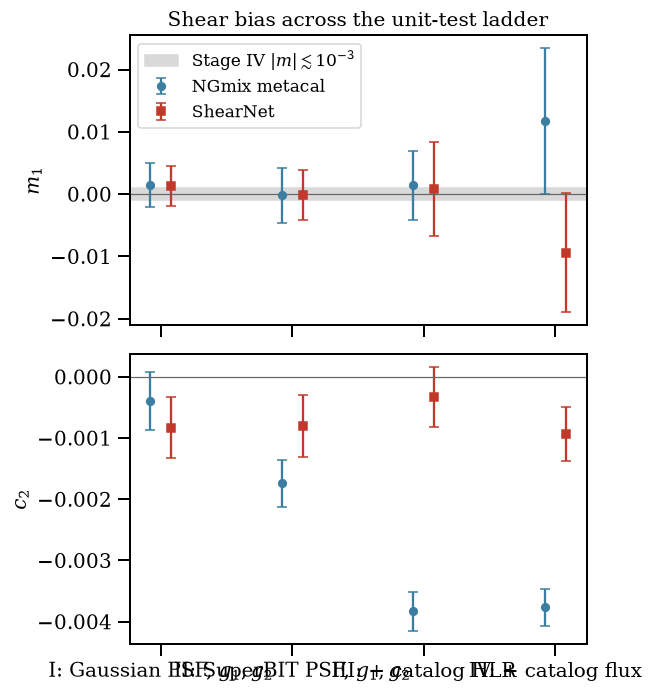

saved -> tab_bias.tex
% tab:bias -- m1 in units of 1e-3, c2 in units of 1e-4, jackknife errors
% columns: tier & method & m1 [1e-3] & c2 [1e-4]
first & NGmix metacalibration & $+1.50 \pm 3.58$ & $-3.89 \pm 4.76$ \\
first & \textsc{ShearNet} & $+1.37 \pm 3.22$ & $-8.29 \pm 4.97$ \\
second & NGmix metacalibration & $-0.21 \pm 4.35$ & $-17.42 \pm 3.76$ \\
second & \textsc{ShearNet} & $-0.15 \pm 4.00$ & $-8.05 \pm 5.05$ \\
third & NGmix metacalibration & $+1.41 \pm 5.58$ & $-38.31 \pm 3.23$ \\
third & \textsc{ShearNet} & $+0.81 \pm 7.52$ & $-3.33 \pm 4.89$ \\
fourth & NGmix metacalibration & $+11.71 \pm 11.69$ & $-37.67 \pm 3.06$ \\
fourth & \textsc{ShearNet} & $-9.37 \pm 9.58$ & $-9.33 \pm 4.42$ \\



In [4]:
# ---- bias ladder figure + LaTeX table ----
if BIAS:
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6.0, 6.4), sharex=True)
    tiers = [t for t in TIERS if t in BIAS]
    x = np.arange(len(tiers))
    for meth, style, dx in [("ngmix", M_NG, -0.08), ("shearnet", M_SN, +0.08)]:
        vals = [(BIAS[t][meth] if meth in BIAS[t] else (np.nan,)*4) for t in tiers]
        m,  me = np.array([v[0] for v in vals]), np.array([v[1] for v in vals])
        c,  ce = np.array([v[2] for v in vals]), np.array([v[3] for v in vals])
        ax0.errorbar(x + dx, m, yerr=me, ls="", capsize=3, ms=5, **style)
        ax1.errorbar(x + dx, c, yerr=ce, ls="", capsize=3, ms=5, **style)
    ax0.axhspan(-STAGE_IV, STAGE_IV, color="0.85", zorder=0,
                label=r"Stage IV $|m|\lesssim 10^{-3}$")
    ax0.axhline(0, color="0.4", lw=0.8); ax1.axhline(0, color="0.4", lw=0.8)
    ax0.set_ylabel(r"$m_1$"); ax1.set_ylabel(r"$c_2$")
    ax1.set_xticks(x, [TIER_LABEL[t] for t in tiers])
    ax0.legend(); ax0.set_title("Shear bias across the unit-test ladder")
    fig.tight_layout(); savefig(fig, "unit_tests_bias_ladder.pdf"); plt.show()

    rows = []
    for t in tiers:
        for meth, name in [("ngmix", "NGmix metacalibration"), ("shearnet", r"\textsc{ShearNet}")]:
            if meth not in BIAS[t]: continue
            m, me, c, ce = BIAS[t][meth]
            rows.append(f"{t} & {name} & ${m*1e3:+.2f} \\pm {me*1e3:.2f}$ & "
                        f"${c*1e4:+.2f} \\pm {ce*1e4:.2f}$ \\\\")
    tex = ("% tab:bias -- m1 in units of 1e-3, c2 in units of 1e-4, jackknife errors\n"
           "% columns: tier & method & m1 [1e-3] & c2 [1e-4]\n" + "\n".join(rows) + "\n")
    write_tex("tab_bias.tex", tex)
    print(tex)

## PSF leakage (`fig:psf_leakage` + $\alpha$ ladder)

Recovered shear on unsheared galaxies vs the PSF ellipticity used to convolve
them, drawn with **superbit-lensing's `PSFLeakagePanelMaker`** rather than a
hand-rolled plot — it owns the percentile binning, the jackknife $\alpha$ (with
significance labels), the legend/tick styling, and the **$R_{\rm PSF}$ leakage
correction** added in the recent push.

Per tier, one row of panels ($e_1^{\rm PSF}$, $e_2^{\rm PSF}$) per estimator:
NGmix uses the response-corrected `g` **with** the panel maker's $R_{\rm PSF}$
correction (it deconvolves, so the metacal PSF response is physical); ShearNet
uses `g_sn_raw`, its measurement on the real images, **without** the correction
(for a non-deconvolving network the metacal response measures out-of-distribution
sensitivity, not leakage). Toggle either via `CORRECT_PSF_NGMIX` /
`CORRECT_PSF_SHEARNET`. Each tier also writes its binned points and fit scalars
to `psf_leakage_panels_<tier>.fits` in the superbit-lensing panel format, so
`plot_psf_leakage_comparison` can overlay tiers or runs directly.

The ladder figure plots $|\alpha|$ on a **log** axis: tier I (Gaussian PSF)
leaks orders of magnitude more than the later tiers, and on a linear axis that
single point flattens everything else into the baseline. Sign is carried by the
marker fill (filled $=\alpha>0$, open $=\alpha<0$).

[first] ngmix     alpha_1 = -0.03520 +/- 0.00705   alpha_2 = -0.03165 +/- 0.00487   [R_psf corrected]
[first] shearnet  alpha_1 = +0.30113 +/- 0.00645   alpha_2 = +0.33236 +/- 0.00358
saved -> psf_leakage_first.pdf


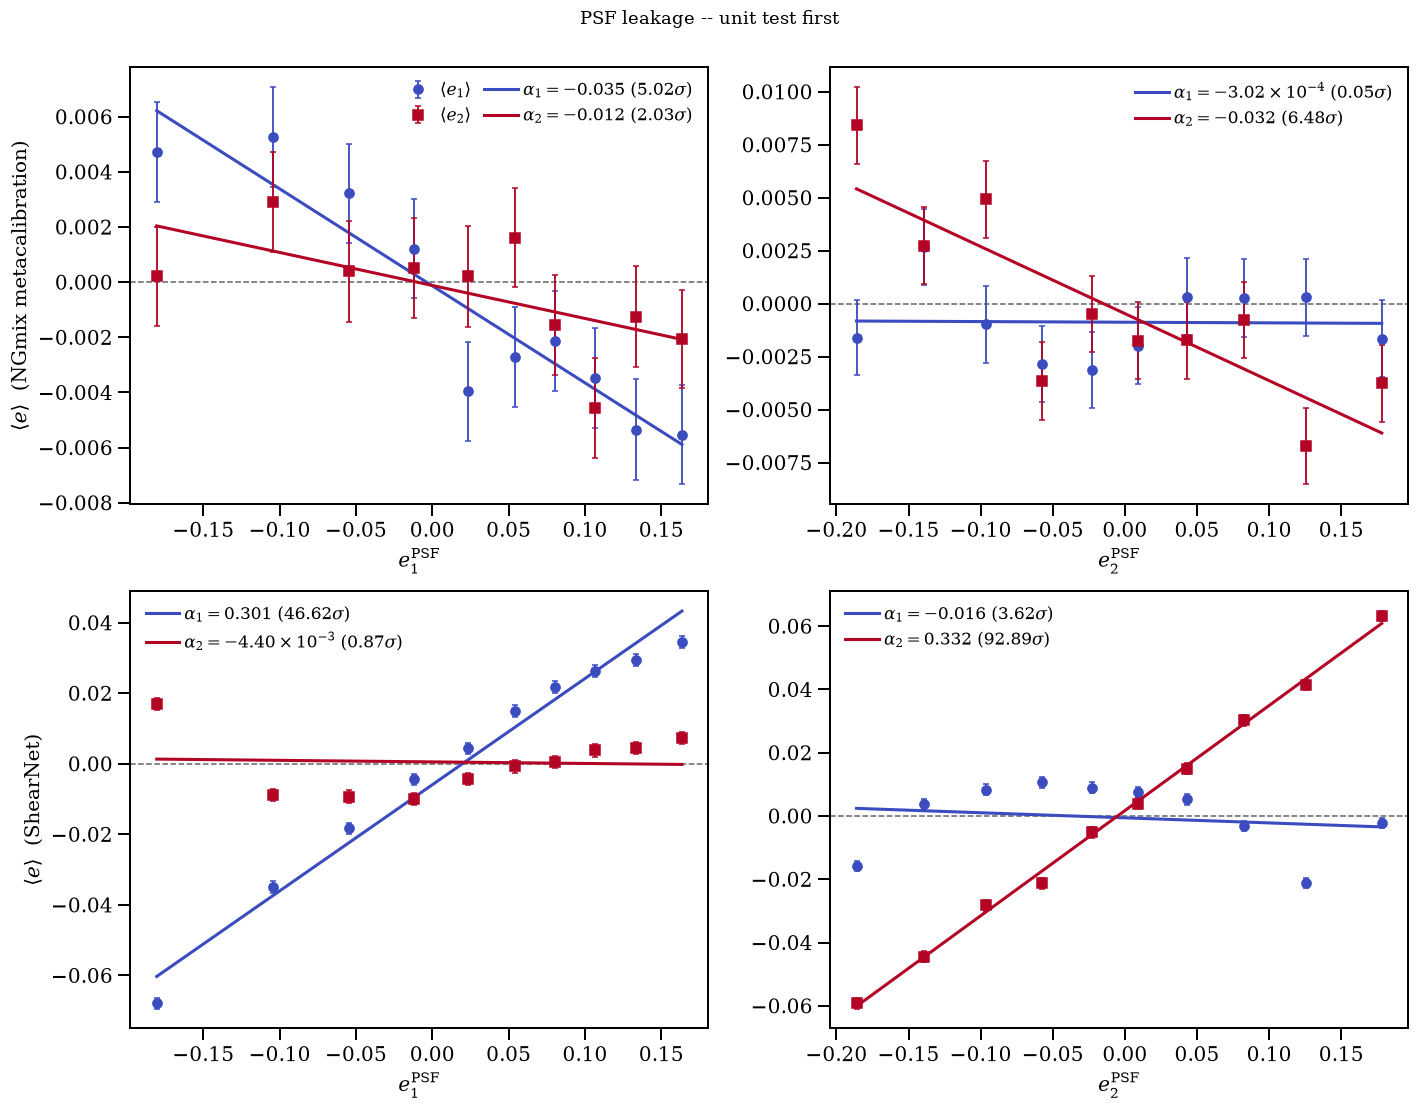

[WROTE] /home/adfield/ShearNet/notebooks/paper_plots/psf_leakage_panels_first.fits  (4 extensions)
[second] ngmix     alpha_1 = -0.03520 +/- 0.00705   alpha_2 = -0.03165 +/- 0.00487   [R_psf corrected]
[second] shearnet  alpha_1 = +0.00245 +/- 0.00692   alpha_2 = -0.00785 +/- 0.00474
saved -> psf_leakage_second.pdf


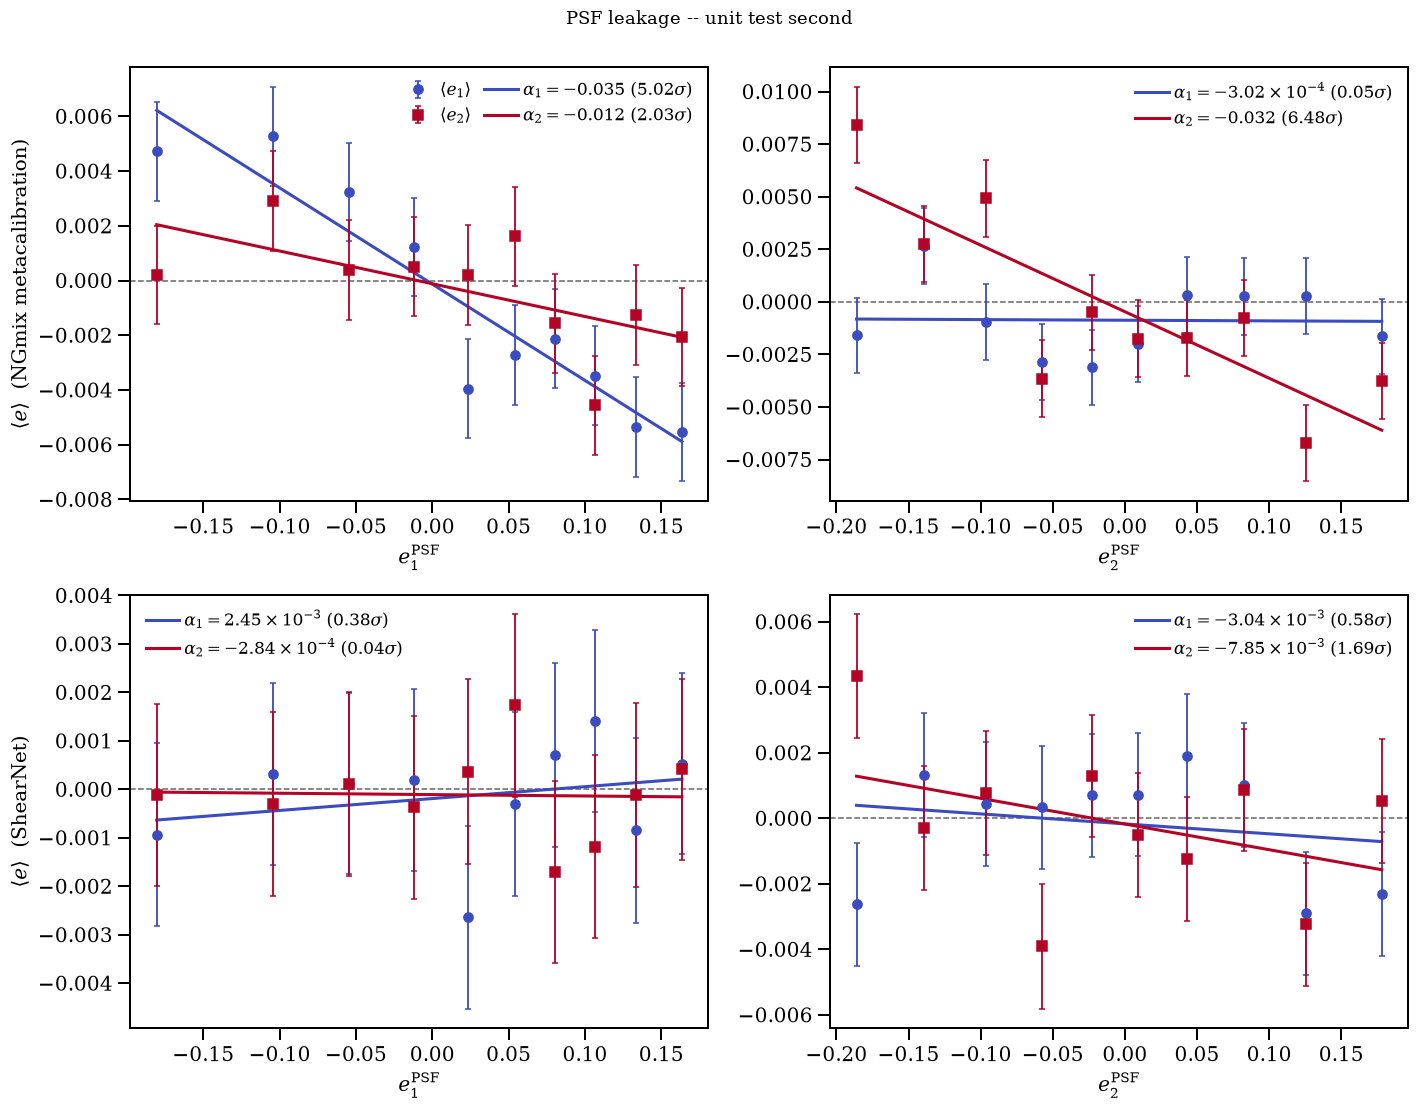

[WROTE] /home/adfield/ShearNet/notebooks/paper_plots/psf_leakage_panels_second.fits  (4 extensions)
[third] ngmix     alpha_1 = -0.03553 +/- 0.00687   alpha_2 = -0.05575 +/- 0.00575   [R_psf corrected]
[third] shearnet  alpha_1 = -0.00479 +/- 0.00667   alpha_2 = -0.00060 +/- 0.00546
saved -> psf_leakage_third.pdf


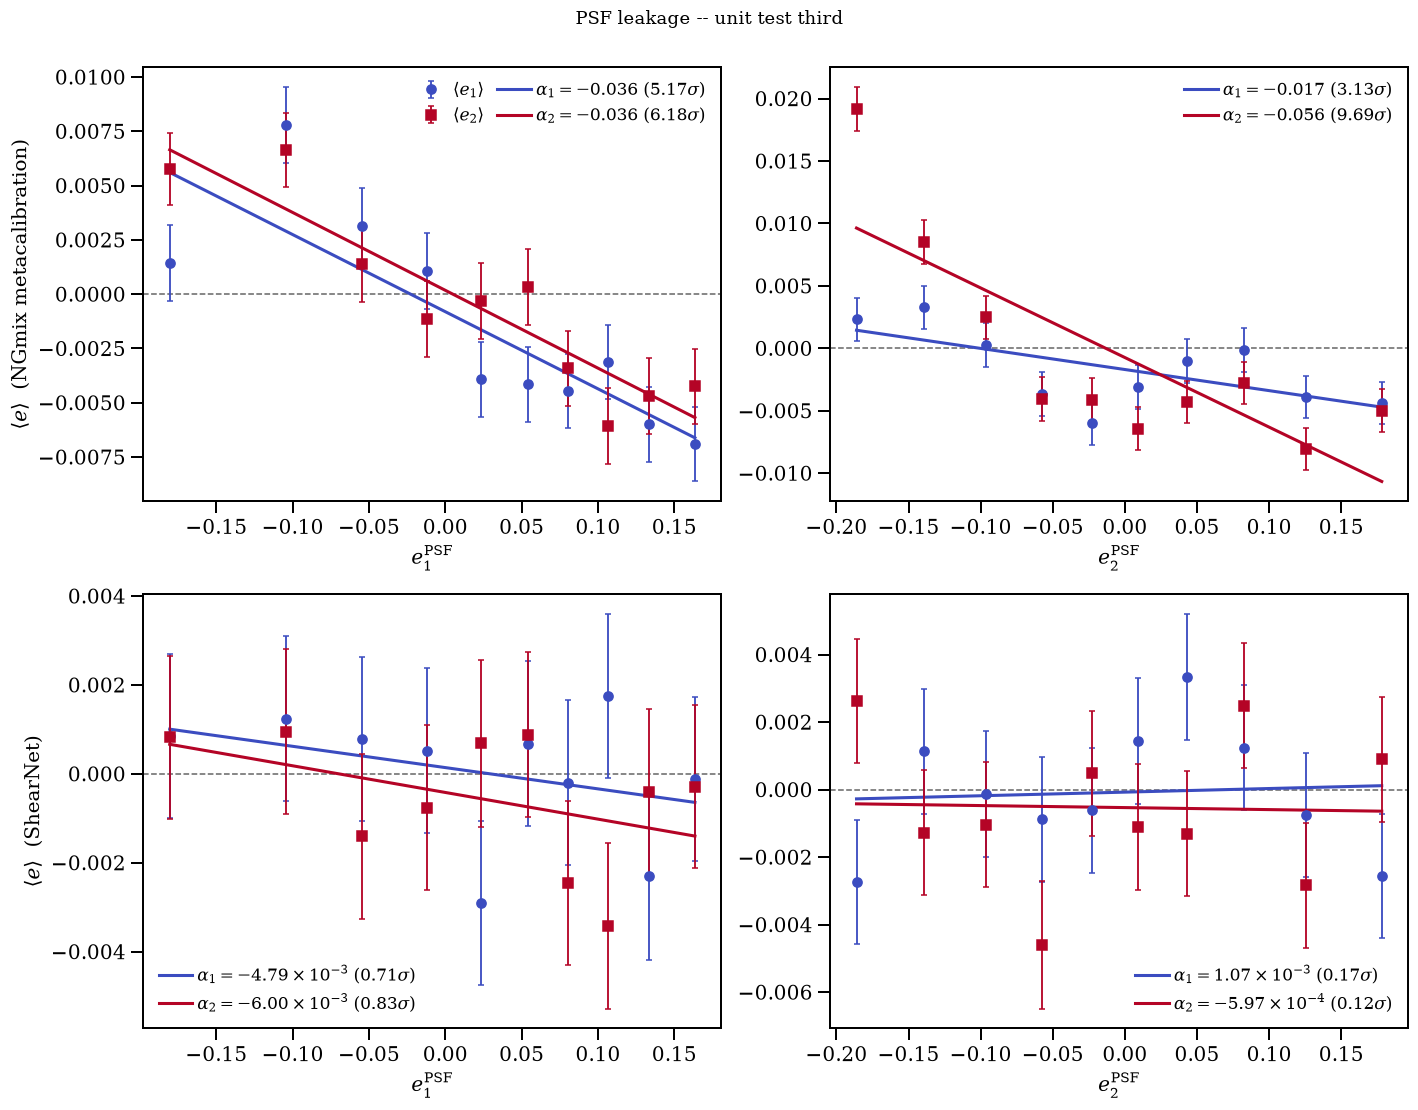

[WROTE] /home/adfield/ShearNet/notebooks/paper_plots/psf_leakage_panels_third.fits  (4 extensions)
[fourth] ngmix     alpha_1 = -0.06427 +/- 0.00583   alpha_2 = -0.10218 +/- 0.00594   [R_psf corrected]
[fourth] shearnet  alpha_1 = +0.00448 +/- 0.00616   alpha_2 = -0.00802 +/- 0.00490
saved -> psf_leakage_fourth.pdf


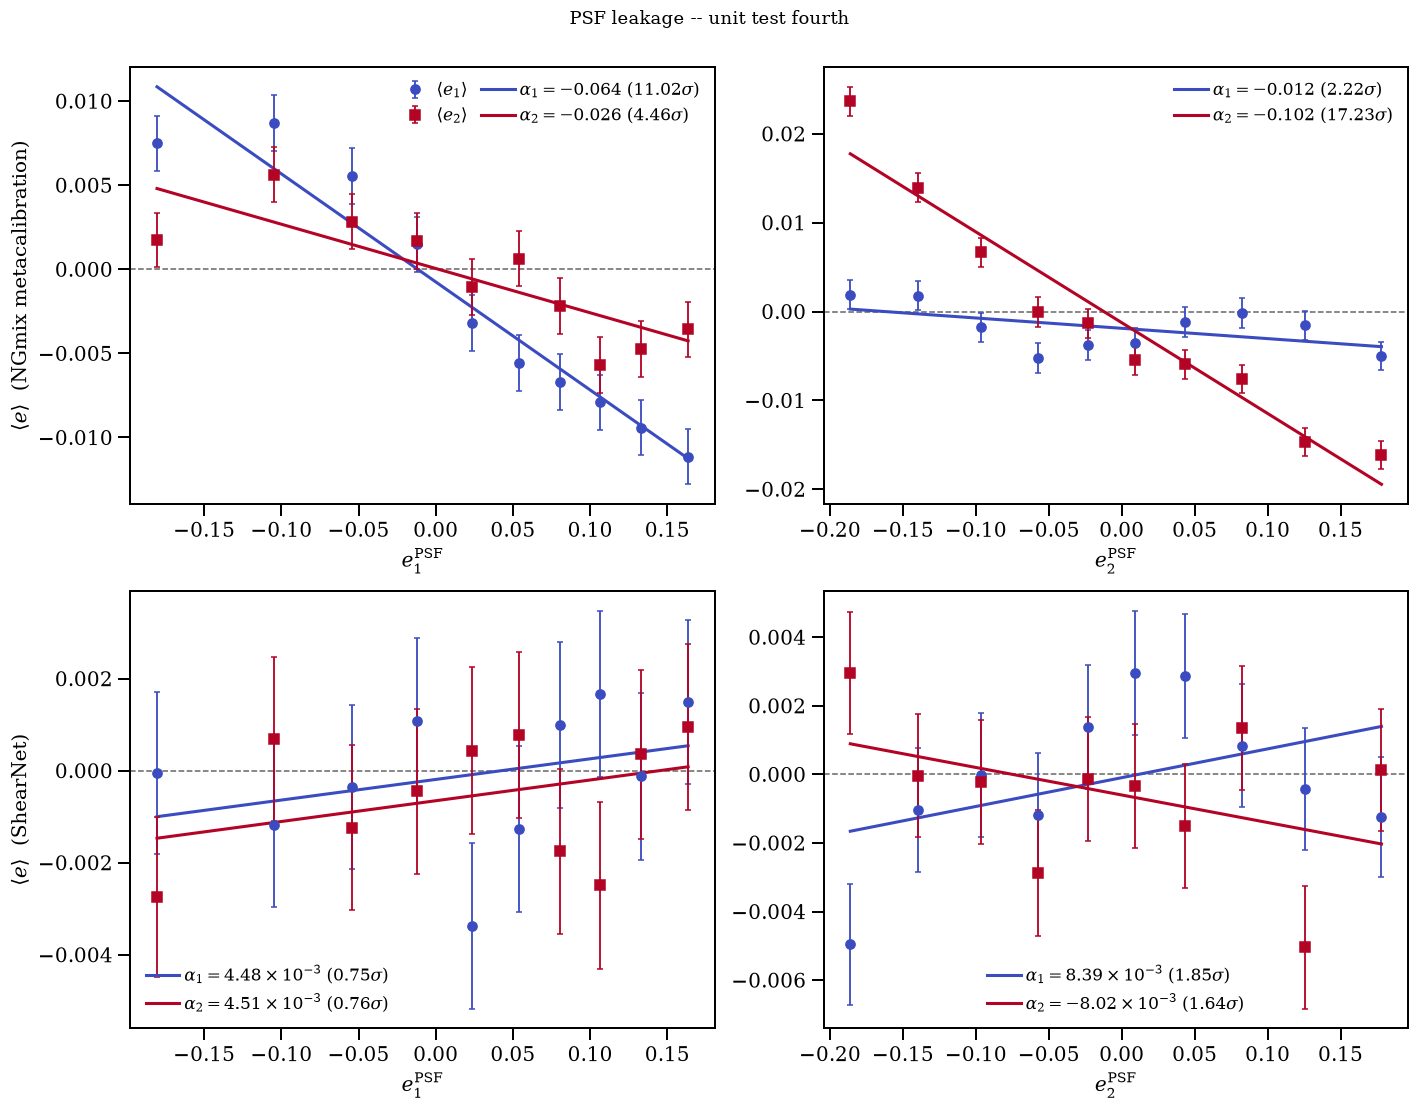

[WROTE] /home/adfield/ShearNet/notebooks/paper_plots/psf_leakage_panels_fourth.fits  (4 extensions)


In [5]:
# ---- per-tier leakage panels via superbit-lensing PSFLeakagePanelMaker ----
# The panel maker owns the binning, the jackknife alpha (+ sigma labels), the
# legend/tick styling, and the R_psf leakage correction. We only feed it columns.
def panel_maker(lk, gal_col, correct_psf, r11_col="r11_psf", r22_col="r22_psf"):
    """Build a PSFLeakagePanelMaker for one estimator from a leakage table."""
    gal  = np.asarray(lk[gal_col], float)
    gpsf = np.asarray(lk["gpsf"], float)
    n = len(gal)
    # r11_psf / r22_psf are the per-object PSF responses; fall back to the stored
    # ensemble Rbar (or zeros) when a column is absent, so the maker still runs.
    def _resp(col, rbar_col):
        if col in lk.colnames:
            return np.asarray(lk[col], float)
        if rbar_col in lk.colnames:
            return np.full(n, float(np.asarray(lk[rbar_col], float)[0]))
        return np.zeros(n)
    return PSFLeakagePanelMaker(
        e1_gal=gal[:, 0], e2_gal=gal[:, 1],
        e1_psf=gpsf[:, 0], e2_psf=gpsf[:, 1],
        r11_psf=_resp(r11_col, "rbar_psf"), r22_psf=_resp(r22_col, "rbar_psf"),
        NBIN=LK_NBIN, MIN_COUNT=LK_MIN_COUNT, njac=LK_NJAC,
        correct_psf_leakage=correct_psf,
    )

ALPHA = {}   # ALPHA[tier][method] = [(a1, a1e), (a2, a2e)]
for t in TIERS:
    r = RES[t]
    if "lk" not in r:
        print(f"[{t}] no leakage fits -- skipped"); continue
    lk = r["lk"]
    gpsf = np.asarray(lk["gpsf"], float)

    # ngmix uses the response-corrected g (+ the maker's R_psf correction);
    # ShearNet uses its raw real-image measurement, uncorrected.
    methods = [("ngmix", "g", CORRECT_PSF_NGMIX, "NGmix metacalibration")]
    if "g_sn_raw" in lk.colnames and np.isfinite(np.asarray(lk["g_sn_raw"], float)).any():
        methods.append(("shearnet", "g_sn_raw", CORRECT_PSF_SHEARNET, "ShearNet"))

    ALPHA[t] = {}
    fig, axes = plt.subplots(len(methods), 2,
                             figsize=(13.0, 5.0 * len(methods)), squeeze=False)
    panel_data = []
    for row, (meth, gcol, corr, disp) in enumerate(methods):
        pm = panel_maker(lk, gcol, corr)
        d1 = pm.make_panel(axes[row][0], x_psf=gpsf[:, 0], xlab=r"$e_1^{\rm PSF}$",
                           showe1e2_leg=(row == 0), return_data=True)
        d2 = pm.make_panel(axes[row][1], x_psf=gpsf[:, 1], xlab=r"$e_2^{\rm PSF}$",
                           return_data=True)
        axes[row][0].set_ylabel(rf"$\langle e \rangle$  ({disp})")
        # alpha_i is the slope of component i against the same-component PSF
        ALPHA[t][meth] = [(d1["alpha_full_1"], d1["alpha_err_1"]),
                          (d2["alpha_full_2"], d2["alpha_err_2"])]
        panel_data += [(f"E1PSF_{meth.upper()}", d1), (f"E2PSF_{meth.upper()}", d2)]
        print(f"[{t}] {meth:9s} alpha_1 = {d1['alpha_full_1']:+.5f} +/- {d1['alpha_err_1']:.5f}   "
              f"alpha_2 = {d2['alpha_full_2']:+.5f} +/- {d2['alpha_err_2']:.5f}"
              f"{'   [R_psf corrected]' if corr else ''}")
    fig.suptitle(f"PSF leakage -- unit test {t}", y=1.005)
    fig.tight_layout(); savefig(fig, f"psf_leakage_{t}.pdf"); plt.show()

    # binned points + fit scalars alongside the PDF, in the superbit-lensing
    # panel format (readable by plot_psf_leakage_comparison)
    save_all_panels_to_fits(str(OUT_DIR / f"psf_leakage_panels_{t}.fits"), panel_data)

saved -> unit_tests_alpha_ladder.pdf


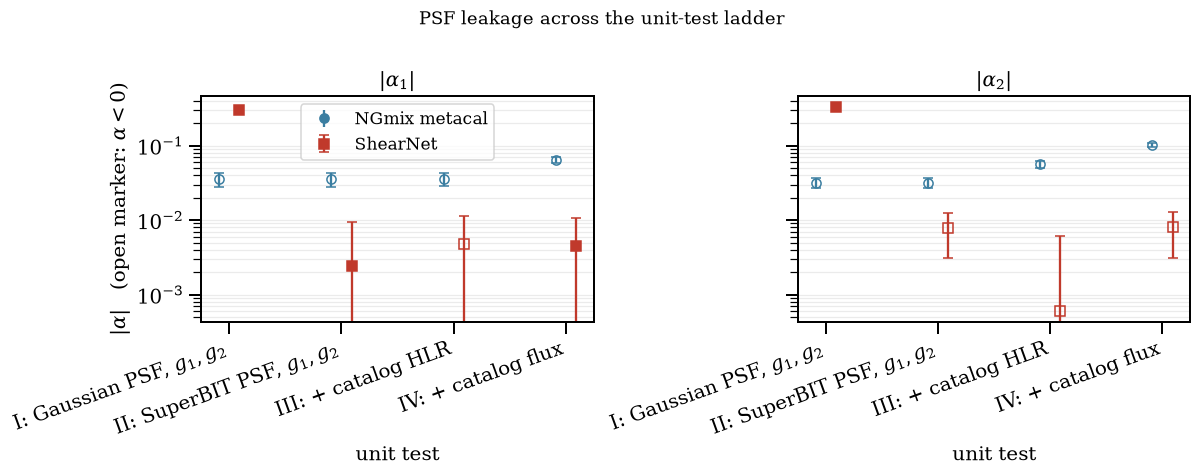

saved -> tab_alpha.tex
% fig:psf_leakage legend values / alpha table
% columns: tier & method & alpha_1 & alpha_2
first & NGmix metacalibration & $-0.0352 \pm 0.0070$ & $-0.0316 \pm 0.0049$ \\
first & \textsc{ShearNet} & $+0.3011 \pm 0.0065$ & $+0.3324 \pm 0.0036$ \\
second & NGmix metacalibration & $-0.0352 \pm 0.0070$ & $-0.0316 \pm 0.0049$ \\
second & \textsc{ShearNet} & $+0.0025 \pm 0.0069$ & $-0.0078 \pm 0.0047$ \\
third & NGmix metacalibration & $-0.0355 \pm 0.0069$ & $-0.0558 \pm 0.0057$ \\
third & \textsc{ShearNet} & $-0.0048 \pm 0.0067$ & $-0.0006 \pm 0.0055$ \\
fourth & NGmix metacalibration & $-0.0643 \pm 0.0058$ & $-0.1022 \pm 0.0059$ \\
fourth & \textsc{ShearNet} & $+0.0045 \pm 0.0062$ & $-0.0080 \pm 0.0049$ \\



In [6]:
# ---- alpha ladder across the tiers + LaTeX ----
# Tier I (Gaussian PSF) leaks orders of magnitude harder than the later tiers, so
# a linear y-axis is dominated by that one point and hides all later structure.
# Plot |alpha| on a LOG axis (sign shown by marker fill: filled = positive,
# open = negative) so every tier is legible at its own scale.
if ALPHA:
    tiers = [t for t in TIERS if t in ALPHA]
    x = np.arange(len(tiers))
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
    for comp, ax in enumerate(axes):
        for meth, style, dx in [("ngmix", M_NG, -0.09), ("shearnet", M_SN, +0.09)]:
            a  = np.array([ALPHA[t][meth][comp][0] if meth in ALPHA[t] else np.nan for t in tiers])
            ae = np.array([ALPHA[t][meth][comp][1] if meth in ALPHA[t] else np.nan for t in tiers])
            pos = a >= 0
            # |alpha| on log; error bars propagate unchanged under the abs
            ax.errorbar(x[pos] + dx, np.abs(a[pos]), yerr=ae[pos], ls="", capsize=3, ms=6,
                        mfc=style["color"], **style)
            ax.errorbar(x[~pos] + dx, np.abs(a[~pos]), yerr=ae[~pos], ls="", capsize=3, ms=6,
                        mfc="none", **{k: v for k, v in style.items() if k != "label"})
        ax.set_yscale("log")
        ax.set_xticks(x, [TIER_LABEL[t] for t in tiers], rotation=20, ha="right")
        ax.set_xlabel("unit test")
        ax.set_title(rf"$|\alpha_{comp+1}|$")
        ax.grid(True, which="both", axis="y", alpha=0.25)
    axes[0].set_ylabel(r"$|\alpha|$   (open marker: $\alpha<0$)")
    axes[0].legend(loc="best")
    fig.suptitle("PSF leakage across the unit-test ladder", y=1.02)
    fig.tight_layout(); savefig(fig, "unit_tests_alpha_ladder.pdf"); plt.show()

    rows = []
    for t in tiers:
        for meth, name in [("ngmix", "NGmix metacalibration"), ("shearnet", r"\textsc{ShearNet}")]:
            if meth not in ALPHA[t]: continue
            (a1, a1e), (a2, a2e) = ALPHA[t][meth]
            rows.append(f"{t} & {name} & ${a1:+.4f} \\pm {a1e:.4f}$ & "
                        f"${a2:+.4f} \\pm {a2e:.4f}$ \\\\")
    tex = ("% fig:psf_leakage legend values / alpha table\n"
           "% columns: tier & method & alpha_1 & alpha_2\n" + "\n".join(rows) + "\n")
    write_tex("tab_alpha.tex", tex)
    print(tex)

## Bias vs S/N and size (`fig:snr_size`)

m recomputed in bins of galaxy S/N and of size ratio $T/T_{\rm PSF}$ (both
taken from the unsheared NGmix measurement of the + catalog, so the binning is
identical for the two methods). Jackknife errors within each bin.

saved -> m_vs_snr_size_first.pdf


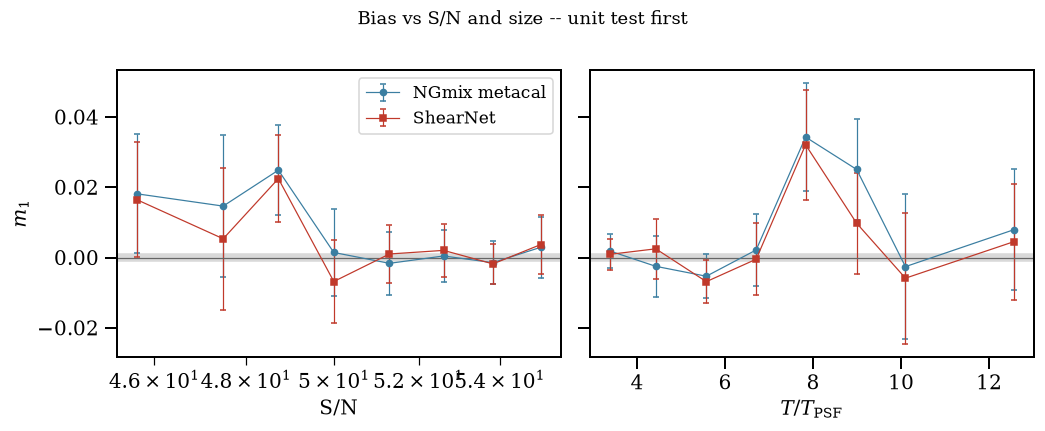

saved -> m_vs_snr_size_second.pdf


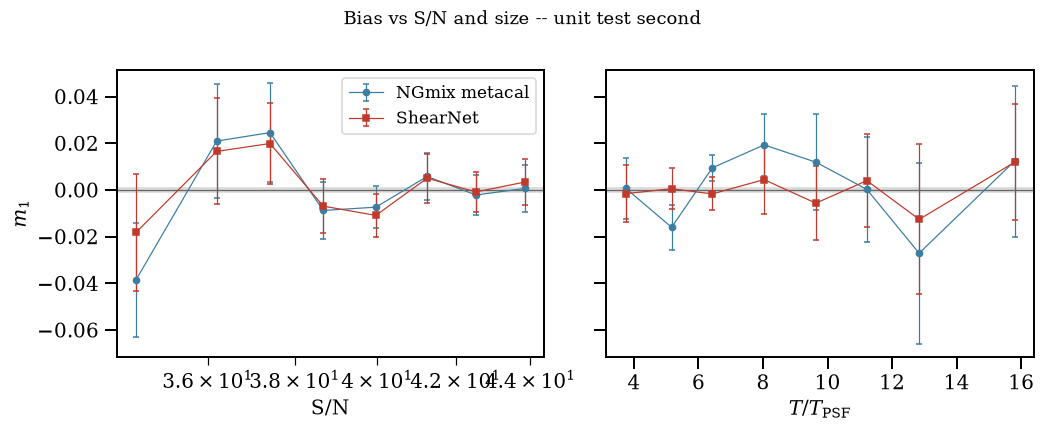

saved -> m_vs_snr_size_third.pdf


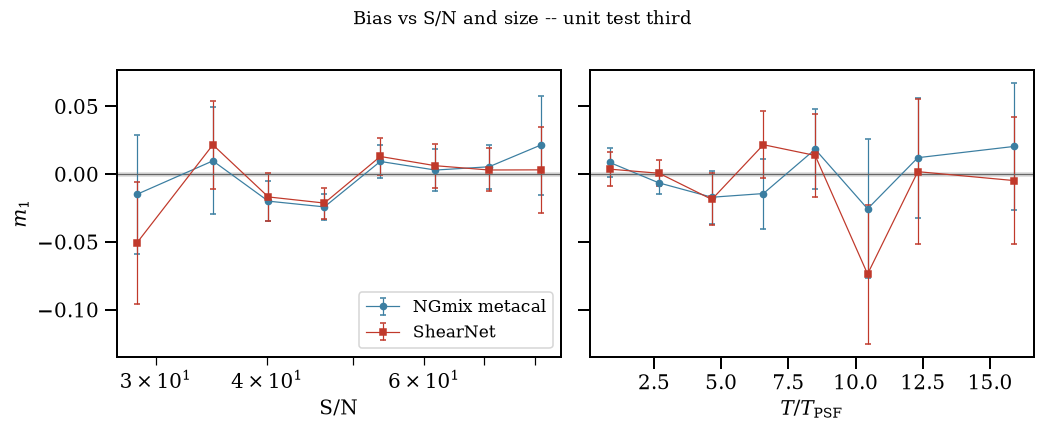

saved -> m_vs_snr_size_fourth.pdf


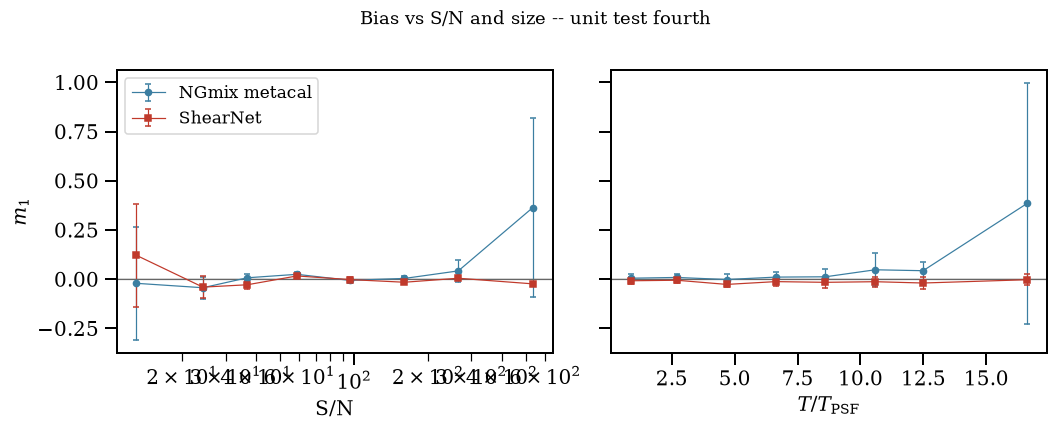

In [7]:
def m_in_bins(tab_p, tab_m, prop, edges, g_col, r11_col):
    g_p, g_m = np.asarray(tab_p[g_col], float), np.asarray(tab_m[g_col], float)
    R = 0.5 * (np.asarray(tab_p[r11_col], float) + np.asarray(tab_m[r11_col], float))
    gamma1 = (g_p[:, 0] - g_m[:, 0]) / 2.0
    idx = np.digitize(prop, edges[1:-1])
    bx, bm, be = [], [], []
    for b in range(len(edges) - 1):
        msk = (idx == b) & np.isfinite(gamma1) & np.isfinite(R) & np.isfinite(prop)
        if msk.sum() < 200: continue
        njac = min(NJAC, max(2, msk.sum() // 100))
        chunks = np.array_split(np.where(msk)[0], njac)
        m_j = []
        for ch in chunks:
            m2 = msk.copy(); m2[ch] = False
            m_j.append(np.nanmean(gamma1[m2]) / np.nanmean(R[m2]) / SHEAR_TRUE - 1)
        m_j = np.array(m_j)
        bx.append(np.nanmedian(prop[msk]))
        bm.append(np.nanmean(gamma1[msk]) / np.nanmean(R[msk]) / SHEAR_TRUE - 1)
        be.append(np.sqrt((njac - 1) * np.mean((m_j - m_j.mean()) ** 2)))
    return map(np.array, (bx, bm, be))

for t in TIERS:
    r = RES[t]
    if "tab_p" not in r: continue
    tp, tm = r["tab_p"], r["tab_m"]
    s2n  = col(tp, "s2n_noshear", "s2n")
    Tgal = col(tp, "T_noshear", "T")
    Tpsf = col(tp, "Tpsf_noshear", "Tpsf")
    panels = []
    if s2n is not None:
        panels.append(("S/N", np.asarray(s2n, float), "log"))
    if Tgal is not None and Tpsf is not None:
        panels.append((r"$T/T_{\rm PSF}$",
                       np.asarray(Tgal, float) / np.asarray(Tpsf, float), "linear"))
    if not panels:
        print(f"[{t}] no s2n/T columns -- skipped"); continue

    fig, axes = plt.subplots(1, len(panels), figsize=(4.8 * len(panels), 3.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (xlabel, prop, xscale) in zip(axes, panels):
        lo, hi = np.nanquantile(prop, [0.01, 0.99])
        edges = (np.geomspace(max(lo, 1e-3), hi, 9) if xscale == "log"
                 else np.linspace(lo, hi, 9))
        for meth, gcol, rcol, style in [("ngmix", "g_noshear", "r11", M_NG),
                                        ("shearnet", "g_sn_noshear", "r11_sn", M_SN)]:
            if gcol not in tp.colnames: continue
            if not np.isfinite(np.asarray(tp[gcol], float)).any(): continue
            bx, bm, be = m_in_bins(tp, tm, prop, edges, gcol, rcol)
            ax.errorbar(bx, bm, yerr=be, ls="-", lw=0.8, capsize=2, ms=4, **style)
        ax.axhspan(-STAGE_IV, STAGE_IV, color="0.85", zorder=0)
        ax.axhline(0, color="0.4", lw=0.8)
        ax.set_xlabel(xlabel); ax.set_xscale(xscale)
    axes[0].set_ylabel(r"$m_1$"); axes[0].legend()
    fig.suptitle(f"Bias vs S/N and size -- unit test {t}", y=1.02)
    fig.tight_layout(); savefig(fig, f"m_vs_snr_size_{t}.pdf"); plt.show()

## Throughput (`tab:timing`) and per-galaxy accuracy (`tab:baseline`)

Timing comes straight from the benchmark npz (throughput in gal/s and the
speedup factor, for whichever of the fair/realistic modes were run). The
accuracy table reports per-galaxy MSE against the stored truths where they
exist: size (ShearNet `g_sn_sigma` vs `gal_hlr_th`; tiers III-IV) and flux
(`g_sn_flux` vs `gal_flux_th`; tier IV), plus the per-pair shear scatter
$\sigma(\gamma_1)$ for both methods (shape noise is common mode, so the
*difference* between methods is the meaningful part). The paper's MSE$(g_1,g_2)$
column against per-galaxy truth requires the standard eval outputs and the
concat-fusion row requires that ablation model -- both left as [XX] here.

In [8]:
# ---- timing table ----
rows = []
for t in TIERS:
    for mode, d in sorted(RES[t].get("timing", {}).items()):
        ng = float(d.get("ngmix_throughput", np.nan))
        sn = float(d.get("shearnet_throughput", np.nan))
        sp = float(d.get("speedup_throughput", np.nan))
        ncpu = int(d["nproc"]) if "nproc" in d else "[NN]"
        rows.append((t, mode, ng, sn, sp, ncpu))
        print(f"[{t}/{mode}] ngmix {ng:9.1f} gal/s ({ncpu} cores)   "
              f"shearnet {sn:9.1f} gal/s (1 GPU)   speedup {sp:6.1f}x")
if rows:
    tex_rows = [f"{t} ({mode}) & NGmix metacalibration & {ncpu} CPU cores & {ng:.0f} \\\\\n"
                f"{t} ({mode}) & \\textsc{{ShearNet}} & 1 GPU & {sn:.0f} \\\\\n"
                f"{t} ({mode}) & Speedup & & ${{\\sim}}{sp:.0f}\\times$ \\\\"
                for t, mode, ng, sn, sp, ncpu in rows]
    tex = ("% tab:timing -- throughput (gal/s)\n" + "\n".join(tex_rows) + "\n")
    write_tex("tab_timing.tex", tex)
else:
    print("no timing npz found in any tier")

no timing npz found in any tier


In [9]:
# ---- per-galaxy accuracy table ----
rows = []
for t in TIERS:
    r = RES[t]
    if "tab_p" not in r: continue
    tp, tm = r["tab_p"], r["tab_m"]
    g_p, g_m = np.asarray(tp["g_noshear"], float), np.asarray(tm["g_noshear"], float)
    gam_ng = (g_p[:, 0] - g_m[:, 0]) / 2.0
    line = {"tier": t, "sig_g_ng": np.nanstd(gam_ng)}
    if "g_sn_noshear" in tp.colnames and np.isfinite(np.asarray(tp["g_sn_noshear"], float)).any():
        gs_p = np.asarray(tp["g_sn_noshear"], float)
        gs_m = np.asarray(tm["g_sn_noshear"], float)
        line["sig_g_sn"] = np.nanstd((gs_p[:, 0] - gs_m[:, 0]) / 2.0)
    hlr_th  = col(tp, "gal_hlr_th");  sn_sig = col(tp, "g_sn_sigma")
    flux_th = col(tp, "gal_flux_th"); sn_flx = col(tp, "g_sn_flux")
    if hlr_th is not None and sn_sig is not None and np.isfinite(sn_sig).any():
        line["mse_sigma"] = np.nanmean((np.asarray(sn_sig) - np.asarray(hlr_th)) ** 2)
    if flux_th is not None and sn_flx is not None and np.isfinite(np.asarray(sn_flx)).any():
        fth = np.asarray(flux_th, float)
        line["mse_flux_rel"] = np.nanmean(((np.asarray(sn_flx) - fth) / fth) ** 2)
    rows.append(line)

if rows:
    hdr = f"{'tier':8s} {'sig(g1) ng':>11s} {'sig(g1) sn':>11s} {'MSE(hlr) sn':>12s} {'relMSE(F) sn':>13s}"
    print(hdr); print("-" * len(hdr))
    tex_rows = []
    for l in rows:
        fmt  = lambda k, s, w: (s.format(l[k]) if k in l else "--".rjust(w))
        fmtx = lambda k, s: (s.format(l[k]) if k in l else "--")
        print(f"{l['tier']:8s} {fmt('sig_g_ng', '{:11.4f}', 11)} {fmt('sig_g_sn', '{:11.4f}', 11)} "
              f"{fmt('mse_sigma', '{:12.3e}', 12)} {fmt('mse_flux_rel', '{:13.3e}', 13)}")
        tex_rows.append(f"{l['tier']} & {fmtx('sig_g_ng', '{:.4f}')} & {fmtx('sig_g_sn', '{:.4f}')} & "
                        f"{fmtx('mse_sigma', '{:.3e}')} & {fmtx('mse_flux_rel', '{:.3e}')} \\\\")
    tex = ("% tab:baseline (partial) -- per-pair shear scatter + MSE vs stored truths\n"
           "% columns: tier & sigma(gamma1) ngmix & sigma(gamma1) shearnet & "
           "MSE(hlr) shearnet & relative MSE(flux) shearnet\n" + "\n".join(tex_rows) + "\n")
    write_tex("tab_baseline.tex", tex)

tier      sig(g1) ng  sig(g1) sn  MSE(hlr) sn  relMSE(F) sn
-----------------------------------------------------------
first         0.0125      0.0127           --            --
second        0.0156      0.0194           --            --
third         0.0224      0.0307    1.234e-04            --
fourth        0.0386      0.0442    3.431e-04     5.096e+06
saved -> tab_baseline.tex


## Scope notes

Produced here, from the three benchmark outputs per tier: the bias ladder
(`unit_tests_bias_ladder.pdf`), per-tier leakage panels + the $|\alpha|$ ladder,
per-tier $m$ vs S/N & size figures, the per-tier leakage panel FITS, and the
bias / alpha / timing / accuracy tables as paste-ready `.tex` rows.

**Plot helpers:** figures use `superbit_lensing.plotter` wherever a helper
exists — `PSFLeakagePanelMaker` for every leakage panel (binning, jackknife
$\alpha$, $R_{\rm PSF}$ correction, styling), `save_all_panels_to_fits` for the
panel records, and `pub_rc` for the publication rcParams. The remaining figures
(bias ladder, $|\alpha|$ ladder, $m$ vs S/N & size) have no counterpart in
superbit-lensing — they are ladder plots specific to this unit-test suite — so
they stay local but reuse `pub_rc` styling and the shared method colors. If a
suitable helper lands upstream, swap them over.

**Not derivable from these files** (tracked separately): the $\rho$-statistics
figure (TreeCorr on reserved-star PSF residuals), `psf_properties_superbit.pdf`
(PSFEx spatial maps — see `make_psfex_shape_maps` upstream), the
MSE$(g_1,g_2)$ column of `tab:baseline` (needs the standard eval outputs) and its
concat-fusion row, and all appendix ablation/hyperparameter tables (separate
notebook once the unit tests are settled). Re-running this notebook refreshes
every PDF, FITS and `.tex` in place.